In [1]:
import torch
import os
import json
from tqdm import tqdm

# 需要定义llava模块的位置，即指定PATH变量
import sys
llava_module_dir = "/root/userfolder/MIL/VL-MIL"
sys.path.insert(0, llava_module_dir)

from llava.mm_utils import get_model_name_from_path
from llava.model.builder import load_pretrained_model
from mil.constants import (
    IMAGE_POS,
    INSTRUCT_POS
)
from feature_utils import (
    generate_hidden_states, 
    matrix_based_entropy
)

import numpy as np 
from entropy_analysis import plot_layer_entropy_stats

/root/userfolder/anaconda3/envs/llava/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/root/userfolder/anaconda3/envs/llava/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [6]:
IMAGE_POS, INSTRUCT_POS

((14, 743), (746, 763))

In [10]:
ifd_test_path = "/root/commonfile/NFI/jsons/descriptions/nfd_valid.json"
model_path = "/root/userfolder/data-ckpts/VL-MIL/checkpoints/v2/llava/merged/llava-onevision-qwen2-7b-si-ft-3epoch-NFD-freeze_backbone_valid_3"
image_folder = "/root/commonfile/InfantVQA"
device='cuda:0'

In [11]:
# 加载 IFD 数据集
with open(ifd_test_path, 'r') as f:
    ifd_data = json.load(f)
ifd_data[0]

{'id': 1000501,
 'image': 'ifd/images/RH/cai_shihongying_1701352_20170522/1.jpg',
 'description': '可见沿视网膜神经纤维走向排列的浅层视网膜出血灶，呈红色。',
 'label': '视网膜出血。',
 'conversations': [{'from': 'human',
   'value': '<image>\nPlease tell me the possible abnormality in the newborn fundus image in Chinese.'},
  {'from': 'gpt',
   'value': '<think>可见沿视网膜神经纤维走向排列的浅层视网膜出血灶，呈红色。</think> <answer>视网膜出血。</answer>.'}]}

加载模型

In [12]:
model_name = get_model_name_from_path(model_path)
tokenizer, model, image_processor, context_len = load_pretrained_model(model_path, None, model_name, device_map=device)

{'device_map': 'cuda:0'}
Loaded LLaVA model: /root/userfolder/data-ckpts/VL-MIL/checkpoints/v2/llava/merged/llava-onevision-qwen2-7b-si-ft-3epoch-NFD-freeze_backbone_valid_3


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Loading vision tower: /root/userfolder/model_weights/siglip-so400m-patch14-384


/root/userfolder/anaconda3/envs/llava/lib/python3.10/site-packages/torch/nn/modules/module.py:2025: UserWarning: for vision_model.embeddings.patch_embedding.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(f'for {key}: copying from a non-meta parameter in the checkpoint to a meta '
/root/userfolder/anaconda3/envs/llava/lib/python3.10/site-packages/torch/nn/modules/module.py:2025: UserWarning: for vision_model.embeddings.patch_embedding.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(f'for {key}: copying from a non-met

Model Class: LlavaQwenForCausalLM


In [16]:
# print("Successfully loaded model")
# assert False, "Stop for resume."

按照病人进行多图描述

In [13]:
# check for outputs
outputs = generate_hidden_states(ifd_data[0], model, tokenizer, image_processor)
for key, value in outputs.items():
    if isinstance(value, torch.Tensor):
        print(key, value.shape)
    elif key == "num_layers":
        print("num_layers", value)
    else:
        print(key, type(value), f"{len(value)}x{value[0].shape[0]}")
        # for layer, vec in enumerate(value):
        #     print(vec.shape)

num_layers 29
siglip_features torch.Size([729, 1152])
input_hidden_states <class 'tuple'> 29x767
output_hidden_states <class 'list'> 29x39


### 
$$
\begin{aligned}
C_{desc} &= [2, 10, 13, 15, 16, 34, 37] \\
C'_{desc} &= [2, 10, 13, 744, 745, 763, 766] \\
\end{aligned}
$$

In [14]:
num_layers = outputs['num_layers']
image_entropy_list = [[] for _ in range(num_layers)]
instruct_entropy_list = [[] for _ in range(num_layers)]
input_entropy_list = [[] for _ in range(num_layers)]
output_entropy_list = [[] for _ in range(num_layers)]

for sample in tqdm(ifd_data):
    features = generate_hidden_states(sample, model, tokenizer, image_processor)
    for layer in range(num_layers):
        input_entropy_list[layer].append(matrix_based_entropy(features["input_hidden_states"][layer]))
        output_entropy_list[layer].append(matrix_based_entropy(features["output_hidden_states"][layer]))
        image_entropy_list[layer].append(matrix_based_entropy(features["input_hidden_states"][layer][IMAGE_POS[0]: IMAGE_POS[1]]))
        instruct_entropy_list[layer].append(matrix_based_entropy(features["input_hidden_states"][layer][INSTRUCT_POS[0]: INSTRUCT_POS[1]]))

100%|██████████| 1034/1034 [2:13:15<00:00,  7.73s/it] 


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import viridis

def plot_layer_entropy_stats(
    *entropy_datas,  # 支持多个熵数据集
    labels=None,
    colors=None,
    layer_names: list = None,
    title='Image Entropy Statistics by Layer',
    font_size=20,
    show_legend=True
):
    """
    绘制各层熵统计数据图表，展示均值及标准差。
    :param entropy_datas: 可变数量的熵数据数组
    :param layer_names: 图层名称列表
    :param title: 主图标题
    :param font_size: 字体大小
    :param show_legend: 是否显示图例
    :return: 返回生成的图形对象
    """
    if labels is None:
        labels = [f"Line {i}" for i in range(len(entropy_datas))]
    if colors is None:
        colors = viridis(np.linspace(0, 1, len(entropy_datas)))  # 根据数据集数量分配颜色
    
    fig1, ax1 = plt.subplots(figsize=(14,6), dpi=100)
    for idx, entropy_data in enumerate(entropy_datas):
        if isinstance(entropy_data, list) and len(entropy_data[0]) == 0:
            entropy_data = entropy_data[1:]
        
        entropy_data = np.array(entropy_data)
        means = np.mean(entropy_data, axis=1)
        std_devs = np.std(entropy_data, axis=1)
        
        # 绘制均值线
        mean_line = ax1.plot(
            range(1, len(means) + 1), means, 'o-', 
            color=colors[idx], linewidth=2, markersize=4, 
            label=f'{labels[idx]} Mean', zorder=5)
        
        # 绘制标准差区间
        ax1.fill_between(
            range(1, len(means) + 1), 
            means - std_devs, means + std_devs, 
            alpha=0.25, color=colors[idx], 
            label=f'{labels[idx]} Dev')
    
    # 创建默认图层名称（如果未提供）
    if layer_names is None:
        layer_names = [i-1 for i in range(len(entropy_data))]
    
    # 设置主图属性
    # ax1.set_title(title, fontsize=font_size+2, pad=15)
    ax1.set_ylabel('Entropy Value', fontsize=font_size+2)
    ax1.set_xlabel('Layer', fontsize=font_size+2)
    ax1.tick_params(axis='both', which='major', labelsize=font_size)
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.set_xlim(0.5, len(layer_names) + 0.5)
    
    # 设置X轴刻度
    ax1.set_xticks(range(1, len(layer_names) + 1))
    ax1.set_xticklabels(layer_names, rotation=45, ha='right', fontsize=font_size)
    
    # 添加图例
    if show_legend:
        ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1),
                  ncol=len(entropy_datas), fontsize=font_size, framealpha=0.9)
    
    # 调整布局
    plt.subplots_adjust(top=0.8, bottom=0.15)
    plt.savefig("Entropy_based_analysis.png")
    plt.show()

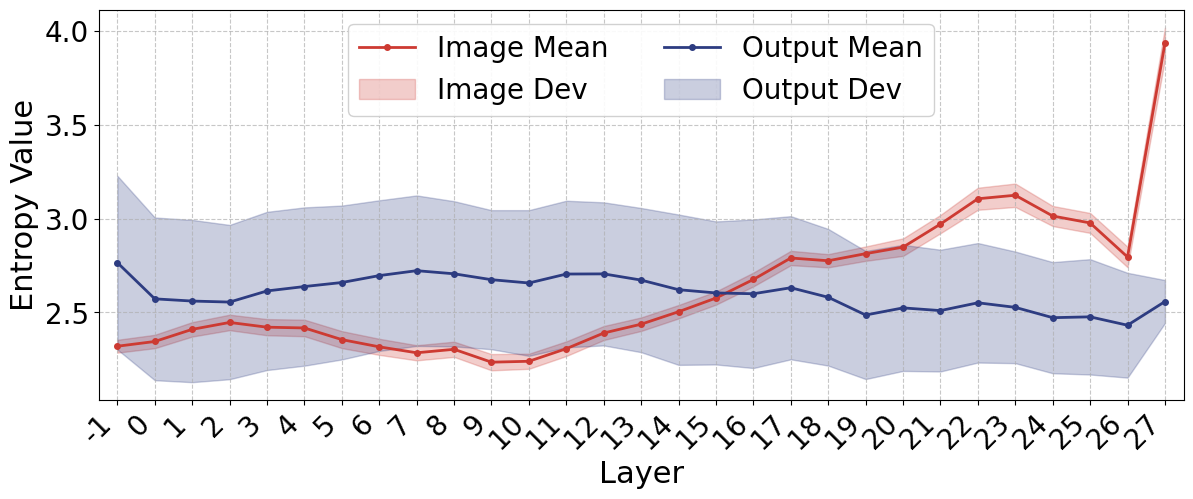

In [29]:
colors = [
    [205, 58, 50, 255],
    # [239, 145, 99, 255],
    # [20, 21, 33, 255],
    [45, 60, 129, 255],
    # [78, 164, 239, 255],
    # [147, 117, 98, 255]
]

plot_layer_entropy_stats(
    np.array(image_entropy_list),
    # np.array(instruct_entropy_list),
    np.array(output_entropy_list),
    # np.array(input_entropy_list),
    # labels = ['Image', 'Prompt', 'Output', 'Input'],
    labels = ['Image', 'Output'],
    colors = np.array(colors) / 255
    )